<h2 align='center'> MÔN HỌC: <br> HỌC MÁY THỐNG KÊ </h2>

---

### Dự đoán khách hàng rời bỏ dịch vụ trong ngành viễn thông
<img src='pic/Top.png' width='400px'>

In [51]:
# Khai báo thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.tree import plot_tree

# Tiền xử lý dữ liệu

In [90]:
# Định nghĩa đường dẫn file CSV
file_path2 = r"Train_ChurnData.csv"

# Đọc dữ liệu từ trang tính được chỉ định vào DataFrame
Train_Data = pd.read_csv(file_path2)
print("Đọc thành công")

Đọc thành công


In [93]:
# Xóa những cột sẽ không sử dụng để dự đoán
Train_Data = Train_Data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)
# Random Forest rất kém trong việc đọc phân loại nên trước khi xây dựng mô hình ta phải chuyển đổi tất cả các cột phân loại thành số
# Danh sách các cột được mã hóa nhãn
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]
# Mã hóa các biến phân loại ngoại trừ biến mục tiêu
# Encoding là quá trình bắt buộc sử dụng các phương pháp mã hóa cụ thể để tạo ra các giá trị/phân nhóm cụ thể cho từng đặc trưng.
label_encoders = {}
# Mã hóa code dựa trên thứ tự bảng chữ cái
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    Train_Data[column] = label_encoders[column].fit_transform(Train_Data[column])

In [96]:
# Mã hóa thủ công biến mục tiêu 'Customer_Status':
Train_Data['Customer_Status'] = Train_Data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Chia dữ liệu thành các tính năng (X) và mục tiêu (y)
X = Train_Data.drop('Customer_Status', axis=1)
y = Train_Data['Customer_Status']

# Train dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Kiểm tra
print("1. Kích thước tập Training: %d" %len(y_train))
print("2. Kích thước tập Test    : %d" %len(y_test))

1. Kích thước tập Training: 4805
2. Kích thước tập Test    : 1202


#  Mô hình Rừng ngẫu nhiên

In [99]:
# Khởi tạo Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

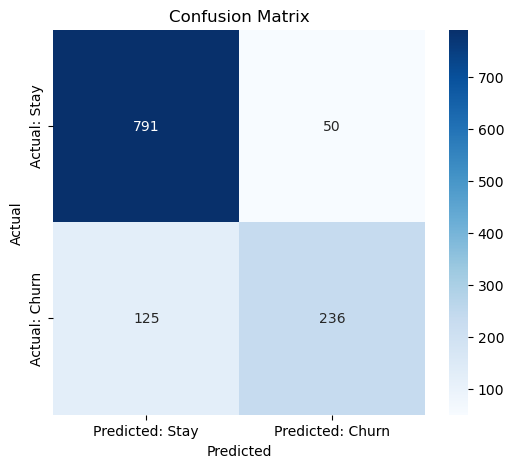


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       841
           1       0.83      0.65      0.73       361

    accuracy                           0.85      1202
   macro avg       0.84      0.80      0.81      1202
weighted avg       0.85      0.85      0.85      1202



In [101]:
# Đưa ra dự đoán
y_pred = rf_model.predict(X_test)

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Vẽ biểu đồ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted: Stay', 'Predicted: Churn'], yticklabels=['Actual: Stay', 'Actual: Churn'])

# Thêm tiêu đề và nhãn
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
# Hiển thị biểu đồ
plt.show()

# Đánh giá model
#print("Confusion Matrix:")
#print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

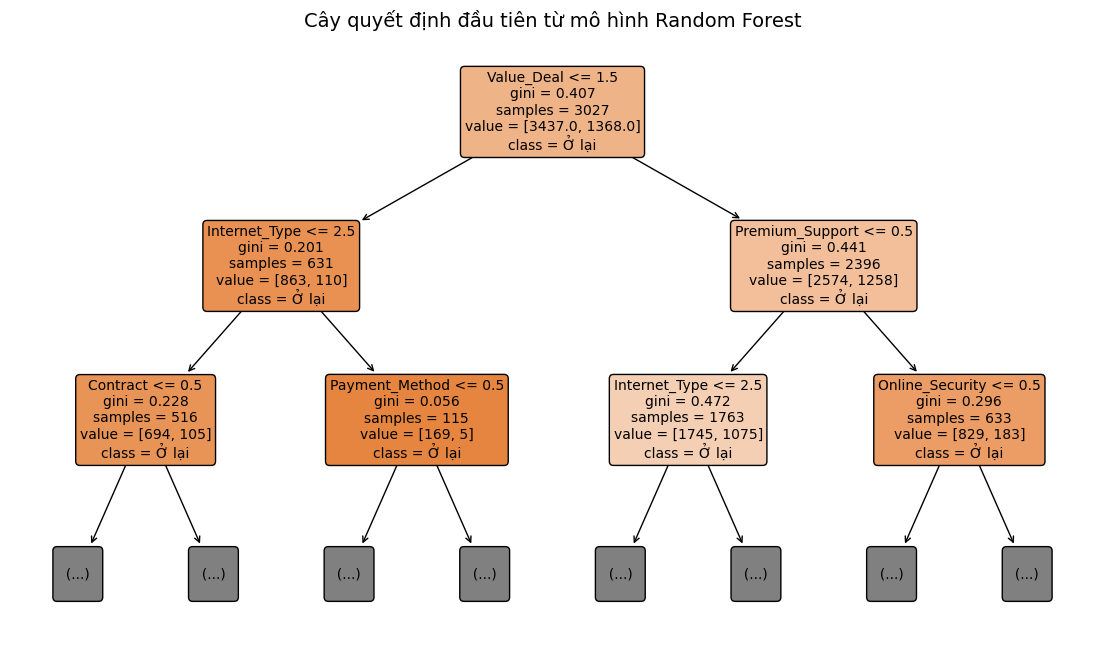

In [105]:
# Lấy cây quyết định đầu tiên từ mô hình Random Forest
tree_model = rf_model.estimators_[0]  # Cây quyết định đầu tiên

# Hiển thị cây quyết định
plt.figure(figsize=(14, 8))  # Tùy chỉnh kích thước biểu đồ
plot_tree(tree_model, 
          feature_names=X_train.columns,  # Tên các đặc trưng
          class_names=["Ở lại", "Rời bỏ"],
          filled=True,  # Tô màu cho các nút
          rounded=True,  # Các nút có góc bo tròn
          fontsize=10,# Kích thước chữ
          max_depth=2)  
plt.title("Cây quyết định đầu tiên từ mô hình Random Forest", fontsize=14)
plt.show()

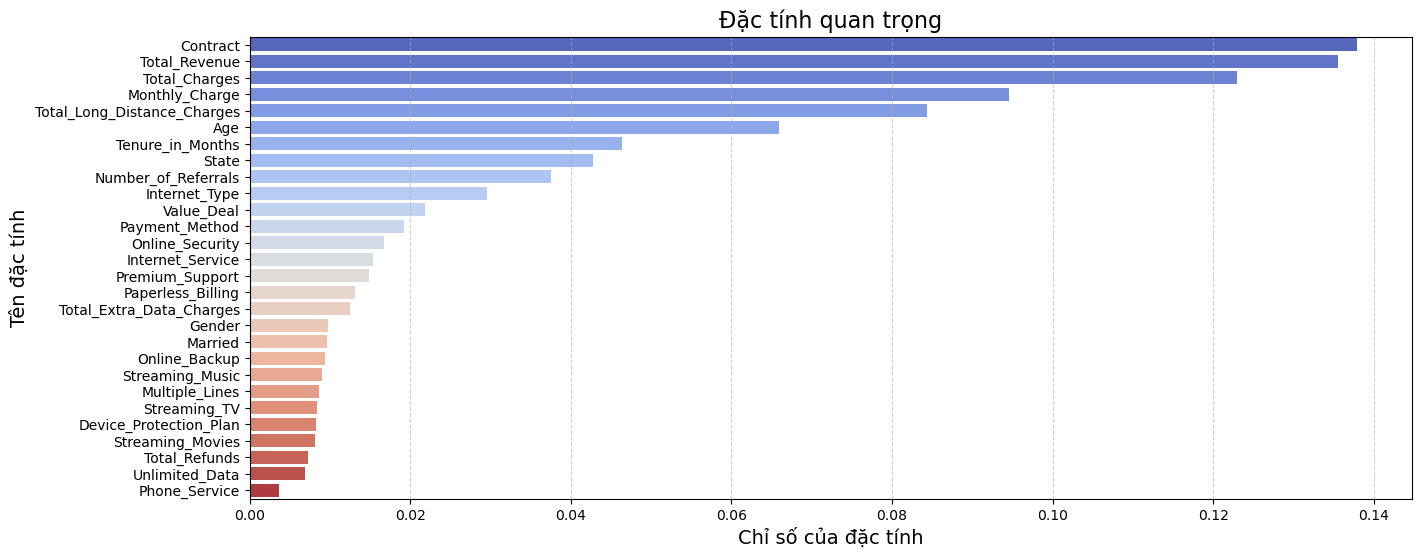

In [107]:
# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Hiển thị những đặc tính quan trọng
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], hue=X.columns[indices], palette="coolwarm", dodge=False)  # Gán hue và bỏ legend
plt.title('Đặc tính quan trọng', fontsize=16)
plt.xlabel('Chỉ số của đặc tính', fontsize=14)
plt.ylabel('Tên đặc tính', fontsize=14)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)  # Đường lưới nhẹ nhàng hơn cho trục x
plt.legend([],[], frameon=False)  # Ẩn legend không cần thiết
plt.show()

### **Nhận xét về mức độ quan trọng của các đặc trưng (Feature Importance):**
1. **Biến quan trọng nhất:**
   - **Contract (Hợp đồng)**: Là yếu tố ảnh hưởng lớn nhất đến khả năng dự đoán rời bỏ, cho thấy loại hợp đồng (theo thời gian dài hay ngắn) có vai trò quyết định lớn.

2. **Các yếu tố tài chính:**
   - **Total Revenue (Tổng doanh thu)** và **Total Charges (Tổng chi phí)**: Hai biến này đứng thứ hai và ba về mức độ quan trọng, phản ánh tác động đáng kể của chi phí và doanh thu đến hành vi của khách hàng.
   - **Monthly Charges (Chi phí hàng tháng)** và **Total Long Distance Charges (Chi phí liên lạc đường dài)**: Cũng có ảnh hưởng lớn, đặc biệt trong việc phản ánh các khoản chi tiêu hàng tháng và phí phát sinh.

3. **Yếu tố hành vi và nhân khẩu học:**
   - **Age (Tuổi)**, **Tenure in Months (Thời gian sử dụng dịch vụ)**, và **Number of Referrals (Số lần giới thiệu)**: Đóng vai trò ở mức trung bình, cho thấy ảnh hưởng vừa phải của các yếu tố liên quan đến thời gian gắn bó và sự tương tác của khách hàng.

4. **Biến ít quan trọng hơn:**
   - **Total Refunds (Tổng số tiền hoàn lại)**, **Unlimited Data (Dữ liệu không giới hạn)**, và **Phone Service (Dịch vụ điện thoại)**: Có mức độ quan trọng thấp nhất, thể hiện ảnh hưởng không đáng kể đến việc dự đoán hành vi rời bỏ.

---

### **Kết luận:**
- **Chiến lược ưu tiên:** Các biến liên quan đến hợp đồng và tài chính (Contract, Total Revenue, Total Charges) cần được ưu tiên khi tối ưu mô hình hoặc phân tích chiến lược kinh doanh.
- **Tối ưu trải nghiệm khách hàng:** Tập trung cải thiện các yếu tố hợp đồng và chi phí, đồng thời xem xét các chiến lược giữ chân khách hàng ở giai đoạn đầu dựa vào **Tenure in Months**.

# Sử dụng mô hình để dự đoán dữ liệu mới

In [111]:
# Xác định đường dẫn tới file Joiner Data
file_path3 = r"Test_ChurnData.csv"

# Đọc dữ liệu từ trang tính được chỉ định vào DataFrame
test_data = pd.read_csv(file_path3)

# Hiển thị thông tin của sheet
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  411 non-null    object 
 1   Gender                       411 non-null    object 
 2   Age                          411 non-null    int64  
 3   Married                      411 non-null    object 
 4   State                        411 non-null    object 
 5   Number_of_Referrals          411 non-null    int64  
 6   Tenure_in_Months             411 non-null    int64  
 7   Value_Deal                   411 non-null    object 
 8   Phone_Service                411 non-null    object 
 9   Multiple_Lines               411 non-null    object 
 10  Internet_Service             411 non-null    object 
 11  Internet_Type                411 non-null    object 
 12  Online_Security              411 non-null    object 
 13  Online_Backup       

#  Mô hình Rừng ngẫu nhiên

In [115]:
# Nếu cột 'Customer_Status' tồn tại, hãy loại bỏ nó (không gây lỗi nếu không có)
test_data = test_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')

# Nếu tệp test có các biến phân loại (categorical), hãy mã hóa chúng như đã làm với dữ liệu train
for column in test_data.select_dtypes(include=['object']).columns:
    test_data[column] = label_encoders[column].transform(test_data[column])

# Sử dụng mô hình đã huấn luyện để dự đoán cho các khách hàng mới
predictions = rf_model.predict(test_data)

# Thêm kết quả dự đoán vào DataFrame ban đầu
test_data['Customer_Status_Predicted'] = predictions

# Hiển thị kết quả
print(test_data[['Customer_Status_Predicted']])

     Customer_Status_Predicted
0                            1
1                            1
2                            1
3                            1
4                            1
..                         ...
406                          1
407                          1
408                          1
409                          1
410                          0

[411 rows x 1 columns]


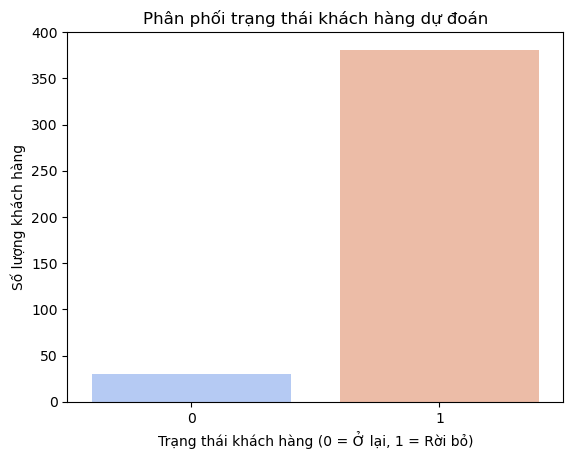

Tỷ lệ % khách hàng rời bỏ: 92.70%
Số KH rời bỏ là:  381


In [117]:
# Hiển thị kết quả dự đoán
# Vẽ biểu đồ phân phối trạng thái khách hàng dự đoán
sns.countplot(x='Customer_Status_Predicted', hue='Customer_Status_Predicted', data=test_data, palette='coolwarm', legend=False)
# Thêm tiêu đề và nhãn
plt.title('Phân phối trạng thái khách hàng dự đoán')
plt.xlabel('Trạng thái khách hàng (0 = Ở lại, 1 = Rời bỏ)')
plt.ylabel('Số lượng khách hàng')
# Tắt chú thích nếu không có 'hue'
plt.legend([],[], frameon=False)  
plt.show()

# Tính số lượng khách hàng rời bỏ
num_churned = test_data[test_data['Customer_Status_Predicted'] == 1].shape[0]

# Tính tổng số khách hàng
total_customers = test_data.shape[0]

# Tính tỷ lệ phần trăm khách hàng rời bỏ
churn_percentage = (num_churned / total_customers) * 100

# In kết quả
print(f"Tỷ lệ % khách hàng rời bỏ: {churn_percentage:.2f}%")
print("Số KH rời bỏ là: ", num_churned)

### **Phân tích biểu đồ trạng thái khách hàng dự đoán:**

1. **Tỷ lệ khách hàng rời bỏ:**
   - **381 khách hàng** (chiếm **92.70%**) được dự đoán sẽ rời bỏ dịch vụ.
   - Tỷ lệ này rất cao, chỉ ra rằng việc rời bỏ là một vấn đề nghiêm trọng cần được quan tâm trong doanh nghiệp.

2. **Tỷ lệ khách hàng ở lại:**
   - Chỉ có **7.3% khách hàng** được dự đoán sẽ ở lại, cho thấy mô hình hoặc dữ liệu có thể thiên lệch, hoặc tình trạng thực tế đang phản ánh khả năng giữ chân khách hàng kém.

3. **Phân phối không đồng đều:**
   - Phân phối mất cân bằng rõ rệt giữa khách hàng rời bỏ và ở lại. Điều này có thể dẫn đến:
     - **Thiên lệch trong mô hình dự đoán**, làm giảm hiệu quả trong việc nhận diện khách hàng trung thành.
     - **Thách thức trong quản lý khách hàng**, yêu cầu doanh nghiệp cần đưa ra biện pháp giữ chân khách hàng hiệu quả hơn.

---

### **Kết luận và khuyến nghị:**
- **Kiểm tra lại dữ liệu và mô hình**: Cần kiểm tra độ chính xác của mô hình, đặc biệt với nhóm khách hàng ở lại, để đảm bảo kết quả không bị thiên lệch.
- **Giảm tỷ lệ rời bỏ**: Tập trung cải thiện chiến lược giữ chân khách hàng bằng các biện pháp như:
  - Cung cấp ưu đãi, gói dịch vụ phù hợp.
  - Nâng cao chất lượng chăm sóc khách hàng.
  - Phân tích sâu hơn các yếu tố ảnh hưởng để dự đoán chính xác hơn.